# Capítulo 1: Tasas de Interés

## 1.1 Interés Simple
El interés simple es la base fundamental de las finanzas porque nos permite modelar el crecimiento del capital de manera constante. En este esquema, el interés se calcula exclusivamente sobre el monto original prestado, sin acumularse sobre sí mismo en periodos siguientes.

La ecuación de equilibrio financiero para el interés simple es:
$$S_t = K_0 + K_0 \cdot i \cdot t$$

Donde:
* **$S_t$**: Saldo en el tiempo $t$ (Valor Futuro)
* **$K_0$**: Capital inicial (Valor Presente)
* **$i$**: Tasa de interés
* **$t$**: Tiempo

### Ejemplo Ilustrativo: El caso de Michael Mayers
Michael Mayers desea comprar una motocicleta que cuesta **30,000 USD**. El banco "Jack Esqueleton" le ofrece una cuenta de ahorro especial con un interés simple del **20% anual**. Si Michael deposita **15,000 USD** al inicio del año, ¿cuántos años deberá dejar su dinero creciendo para alcanzar su meta?

In [237]:
# Variables del problema
K_0 = 15000  # Capital Inicial en USD
S_t = 30000  # Meta (Saldo Final) en USD
i = 0.20     # Tasa de interés simple anual (20%)

# Despejando el tiempo (t) de la fórmula: S_t = K_0 + K_0 * i * t
# t = (S_t - K_0) / (K_0 * i)

t = (S_t - K_0) / (K_0 * i)

print(f"--- RESULTADO DEL ANÁLISIS ---")
print(f"Para transformar {K_0} USD en {S_t} USD a una tasa del {i*100}% anual...")
print(f"Michael Mayers deberá mantener su inversión durante exactamente {int(t)} años.")

--- RESULTADO DEL ANÁLISIS ---
Para transformar 15000 USD en 30000 USD a una tasa del 20.0% anual...
Michael Mayers deberá mantener su inversión durante exactamente 5 años.


## 1.2 Interés Compuesto

A diferencia del modelo lineal, en el interés compuesto el interés se convierte en capital al final de cada periodo. Es el "efecto bola de nieve": el interés generado empieza, a su vez, a generar sus propios intereses.

La fórmula fundamental del interés compuesto es:
$$S_t = K_0(1+i)^t$$

Donde:
* **$S_t$**: Saldo en el tiempo $t$
* **$K_0$**: Capital inicial
* **$i$**: Tasa de interés efectiva del periodo
* **$t$**: Tiempo (en la misma medida que la tasa)

**Concepto Clave:** Para dominar esta fuerza, debemos diferenciar entre **Tasas Nominales** (tasas "de etiqueta" de referencia anual) y **Tasas Efectivas** (las reales, donde el periodo y la frecuencia de capitalización están en perfecta sintonía).

### Ejemplo Ilustrativo: La Paciencia de Freddy K.
Freddy K. ganó hace 30 años un premio de lotería de **25,000 USD**. Tiene la duda existencial: Si lo hubiera depositado en una cuenta con un interés compuesto del **12% anual con capitalización mensual** y se hubiera olvidado de él, ¿cuánto tendría hoy (30 años después)? ¿Y si hubiera esperado 40 años en total?

In [238]:
# Variables del problema
K_0 = 25000       # Capital inicial (Premio) en USD
j = 0.12          # Tasa nominal anual (12%)
m = 12            # Frecuencia de capitalización (12 meses al año)

# 1. Sincronización de la Tasa: Convertimos la nominal anual a efectiva mensual
i_efectiva = j / m

# 2. Sincronización del Tiempo (en meses)
meses_30_anios = 30 * 12
meses_40_anios = 40 * 12

# 3. Cálculo de los saldos usando la fórmula: S_t = K_0 * (1 + i)^t
saldo_30 = K_0 * (1 + i_efectiva)**meses_30_anios
saldo_40 = K_0 * (1 + i_efectiva)**meses_40_anios

print("--- PROYECCIÓN DE INTERÉS COMPUESTO ---")
print(f"Tasa efectiva mensual aplicada: {i_efectiva * 100}%")
print(f"Saldo acumulado a los 30 años: ${saldo_30:,.2f} USD")
print(f"Saldo acumulado a los 40 años: ${saldo_40:,.2f} USD")

--- PROYECCIÓN DE INTERÉS COMPUESTO ---
Tasa efectiva mensual aplicada: 1.0%
Saldo acumulado a los 30 años: $898,741.03 USD
Saldo acumulado a los 40 años: $2,966,193.13 USD


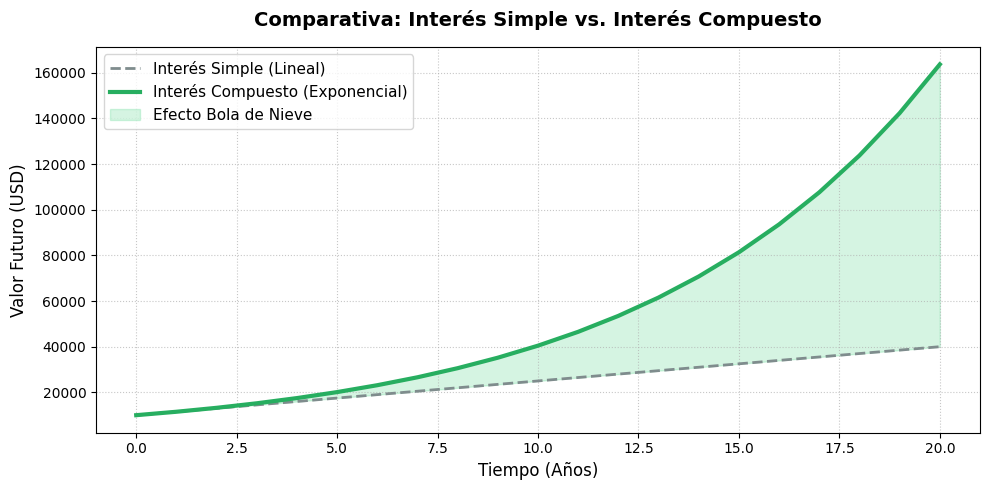

In [239]:
import matplotlib.pyplot as plt
import numpy as np

anios = np.arange(0, 21)
capital_ini = 10000
tasa = 0.15

simple = capital_ini * (1 + tasa * anios)
compuesto = capital_ini * (1 + tasa)**anios

plt.figure(figsize=(10, 5))
plt.style.use('default')

plt.plot(anios, simple, label='Interés Simple (Lineal)', color='#7f8c8d', linestyle='--', linewidth=2)
plt.plot(anios, compuesto, label='Interés Compuesto (Exponencial)', color='#27ae60', linewidth=3)

plt.fill_between(anios, simple, compuesto, color='#2ecc71', alpha=0.2, label='Efecto Bola de Nieve')

plt.title('Comparativa: Interés Simple vs. Interés Compuesto', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tiempo (Años)', fontsize=12)
plt.ylabel('Valor Futuro (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## 1.3 Tasas Equivalentes

Una situación muy común en el ámbito financiero es la necesidad de comparar los rendimientos de varias opciones de inversión diferentes que tienen distintos periodos de capitalización. Para saber cuál es la mejor, necesitamos llevarlas todas a un mismo periodo de referencia usando esta fórmula:

$$(1+i)^{t} = (1+i_e)^{t_e}$$

Donde:
* **$i$**: Tasa de interés conocida
* **$i_e$**: Tasa equivalente que buscamos
* **$t$**: Periodo de tiempo de la tasa conocida
* **$t_e$**: Periodo de tiempo de la tasa equivalente

### Ejemplo Ilustrativo: La Inversión de Jason Voorhees
Jason Voorhees quiere depositar su dinero y tiene tres ofertas. ¿En qué DPF le conviene depositar para ganar más dinero en un año?
* **Banco Krueger:** 2% mensual efectivo.
* **Banco DOOM:** 4% bimestral efectivo.
* **Banco Predator:** 19% efectivo anual.

In [240]:
# Función para calcular tasas anuales equivalentes
def calcular_tasa_anual_equivalente(tasa_efectiva, periodos_por_anio):
    """
    Convierte cualquier tasa efectiva a su equivalente anual.
    Fórmula despejada: i_e = (1 + i)^t - 1
    """
    tasa_anual = ((1 + tasa_efectiva)**periodos_por_anio) - 1
    return tasa_anual

# Ofertas de los bancos
tasa_krueger = 0.02  # 2% mensual (12 periodos al año)
tasa_doom = 0.04     # 4% bimestral (6 periodos al año)
tasa_predator = 0.19 # 19% anual (ya está en términos anuales)

# Calculamos las equivalencias anuales
eq_krueger = calcular_tasa_anual_equivalente(tasa_krueger, 12)
eq_doom = calcular_tasa_anual_equivalente(tasa_doom, 6)

print("--- COMPARATIVA DE TASAS EQUIVALENTES (BASE ANUAL) ---")
print(f"Banco Krueger  : {eq_krueger * 100:.4f}% anual")
print(f"Banco DOOM     : {eq_doom * 100:.4f}% anual")
print(f"Banco Predator : {tasa_predator * 100:.4f}% anual")

print("\nConclusión: El Banco Krueger ofrece la tasa de rendimiento real más alta a lo largo del año.")

--- COMPARATIVA DE TASAS EQUIVALENTES (BASE ANUAL) ---
Banco Krueger  : 26.8242% anual
Banco DOOM     : 26.5319% anual
Banco Predator : 19.0000% anual

Conclusión: El Banco Krueger ofrece la tasa de rendimiento real más alta a lo largo del año.


## 1.5 Inflación (Teorema de Fisher)

La inflación es la pérdida de poder adquisitivo de una moneda[cite: 431]. Para saber cuánto dinero ganamos realmente en una inversión, debemos descontar este efecto. [cite_start]Para cuantificar esto, utilizamos la fórmula del Teorema de Fisher[cite: 434, 435]:

$$1+r = \frac{1+i}{1+\pi}$$

Donde:
* **$r$**: Tasa de rendimiento real 
* **$i$**: Tasa de interés efectiva de la inversión 
* **$\pi$**: Tasa de inflación del periodo

### Ejemplo Ilustrativo: Las Inversiones de Lex Luthor
Lex Luthor tiene inversiones bancarias que le ofrecieron un interés compuesto del **15% efectivo**. Sin embargo, la inflación anual en los últimos tres años fue del **12%, 6% y 8%** respectivamente. ¿Cuál fue su rendimiento real en cada año?

In [241]:
# Variables del problema
i = 0.15  # Tasa de interés efectiva (15%)
inflacion_anual = [0.12, 0.06, 0.08]  # Tasas de inflación de los 3 años

print("--- RENDIMIENTO REAL DE LAS INVERSIONES (TEOREMA DE FISHER) ---")

# Bucle para calcular el rendimiento real (r) de cada año
for anio, pi in enumerate(inflacion_anual, start=1):
    # Despejando r de la fórmula de Fisher: r = ((1 + i) / (1 + pi)) - 1
    r = ((1 + i) / (1 + pi)) - 1
    
    print(f"Año {anio}: Inflación del {pi*100}% -> Rendimiento Real: {r * 100:.4f}%")

--- RENDIMIENTO REAL DE LAS INVERSIONES (TEOREMA DE FISHER) ---
Año 1: Inflación del 12.0% -> Rendimiento Real: 2.6786%
Año 2: Inflación del 6.0% -> Rendimiento Real: 8.4906%
Año 3: Inflación del 8.0% -> Rendimiento Real: 6.4815%


# Capítulo 2: Movimientos Anticipados y Vencidos

## 2.3 Amortización Cuota Constante
En el proceso de pagar una deuda, es vital diferenciar dos conceptos:
1. **La Cuota ($C$)**: El pago total que realizamos al banco cada periodo.
2. **La Amortización ($A$)**: La parte de esa cuota que realmente reduce nuestra deuda original.

La fórmula general para calcular el saldo de una deuda ($S_t$) sujeta a pagos de cuota constante es:

$$S_t = K_0(1+i)^t - C\left[\frac{1-(1+i)^t}{-i}\right]$$

### Ejemplo Ilustrativo: La Baticueva de Bruno Diaz
Bruno Diaz saca un préstamo de **1,000,000 USD** para construir un estacionamiento subterráneo. El banco le ofrece una tasa del **15% anual capitalizable trimestralmente**, pero él hará pagos **mensuales** a cuota constante durante **5 años** (60 meses).

In [242]:
import pandas as pd

# 1. Variables iniciales del préstamo
K_0 = 1000000        # Préstamo inicial (1 millón)
tasa_nominal = 0.15  # 15% anual
plazo_meses = 60     # 5 años

# 2. Sincronización de tasas (Paso crítico del libro)
# La tasa es 15% anual cap. trimestralmente. 
# Primero sacamos la tasa efectiva trimestral (15% / 4)
i_trimestral = tasa_nominal / 4

# Luego hallamos la tasa equivalente mensual usando (1+i)^t = (1+ie)^te
# (1 + i_trimestral)^1 = (1 + i_mensual)^3
i_mensual = (1 + i_trimestral)**(1/3) - 1

print(f"Tasa efectiva mensual calculada: {i_mensual * 100:.4f}%\n")

# 3. Cálculo de la Cuota Constante (Despejada de la fórmula general)
# C = K_0 * (i * (1+i)^t) / ((1+i)^t - 1)
factor = (1 + i_mensual)**plazo_meses
cuota = K_0 * (i_mensual * factor) / (factor - 1)

# 4. Generación del Cuadro de Amortización
saldo = K_0
plan_pagos = []

for mes in range(1, plazo_meses + 1):
    interes_generado = saldo * i_mensual
    amortizacion = cuota - interes_generado
    saldo -= amortizacion
    
    # Prevenir saldos negativos microscópicos por redondeo de Python en el último mes
    if saldo < 0: 
        saldo = 0
        
    plan_pagos.append({
        'Mes': mes,
        'Cuota': round(cuota, 2),
        'Interés': round(interes_generado, 2),
        'Amortización': round(amortizacion, 2),
        'Saldo Restante': round(saldo, 2)
    })

# Convertimos la lista a un DataFrame de Pandas
df_amortizacion = pd.DataFrame(plan_pagos)

# Mostramos solo el primer año (los primeros 12 meses) tal como pide el libro
print("--- PLAN DE PAGOS (PRIMER AÑO) ---")
display(df_amortizacion.head(12))

# 5. Exportación de datos
# Guardamos la tabla completa en un CSV configurado con coma como separador de listas 
# para que se abra y parsee perfectamente de forma nativa en tu hoja de cálculo.
df_amortizacion.to_csv('baticueva_amortizacion.csv', sep=',', index=False)
print("\n¡Tabla completa exportada como 'baticueva_amortizacion.csv'!")

Tasa efectiva mensual calculada: 1.2347%

--- PLAN DE PAGOS (PRIMER AÑO) ---


,Mes,Cuota,Interés,Amortización,Saldo Restante
0,1,23693.62,12346.93,11346.69,988653.31
1,2,23693.62,12206.83,11486.79,977166.52
2,3,23693.62,12065.00,11628.62,965537.90
3,4,23693.62,11921.43,11772.19,953765.71
4,5,23693.62,11776.07,11917.54,941848.17
5,6,23693.62,11628.93,12064.69,929783.48
6,7,23693.62,11479.97,12213.65,917569.83
7,8,23693.62,11329.17,12364.45,905205.37
8,9,23693.62,11176.50,12517.11,892688.26
9,10,23693.62,11021.96,12671.66,880016.60



¡Tabla completa exportada como 'baticueva_amortizacion.csv'!


### 2.3.2 Visualización: Evolución de la Cuota (Capital vs Intereses)

A simple vista en una tabla es difícil dimensionar el costo real del dinero en el tiempo. A continuación, generaremos un gráfico de área que desglosa visualmente la cuota mensual. 

Notaremos el efecto clásico de las amortizaciones a cuota constante (Método Francés): durante los primeros meses, la mayor parte de nuestro pago se destina a cubrir los intereses generados, y la verdadera reducción de la deuda (amortización) ocurre de manera acelerada recién en la recta final del préstamo.

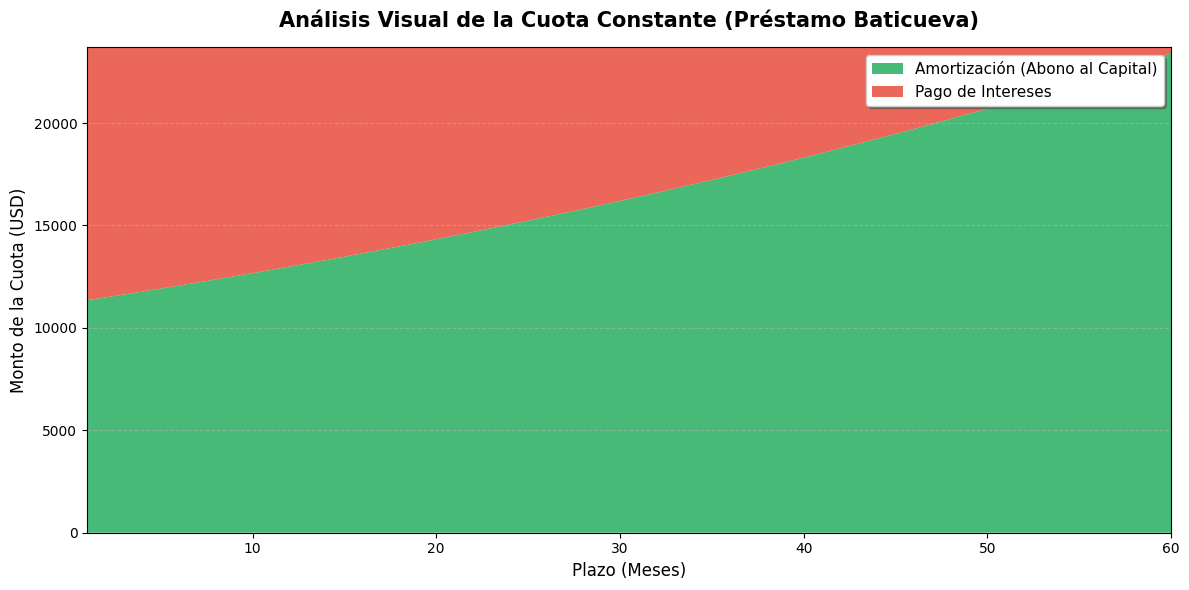

In [243]:
import matplotlib.pyplot as plt

# 1. Configuración del tamaño y estilo del gráfico
plt.figure(figsize=(12, 6))
plt.style.use('default')

# 2. Creación del Gráfico de Área Apilada (Stacked Area Chart)
# Usamos los datos de nuestro DataFrame 'df_amortizacion'
plt.stackplot(
    df_amortizacion['Mes'], 
    df_amortizacion['Amortización'], 
    df_amortizacion['Interés'], 
    labels=['Amortización (Abono al Capital)', 'Pago de Intereses'],
    colors=['#27ae60', '#e74c3c'],  # Verde para capital, Rojo para intereses
    alpha=0.85
)

# 3. Personalización de textos y diseño
plt.title('Análisis Visual de la Cuota Constante (Préstamo Baticueva)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Plazo (Meses)', fontsize=12)
plt.ylabel('Monto de la Cuota (USD)', fontsize=12)

# Añadir la leyenda y la cuadrícula
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Ajustar los bordes para que empiece exactamente en el mes 1 y termine en el 60
plt.xlim(1, df_amortizacion['Mes'].max())
plt.margins(y=0) # Quita el espacio en blanco arriba de la cuota

# 4. Renderizar el gráfico
plt.tight_layout()
plt.show()

## 2.4.1 Amortización Cuota Variable

A diferencia del sistema de cuota constante (método francés), en las amortizaciones de cuota variable (método alemán) no se calcula la amortización en función de la cuota, sino que se escoge la cuota según una amortización que se mantiene estrictamente constante a lo largo de todo el periodo.

Como el capital se reduce de forma constante y acelerada desde el primer mes, los intereses que se calculan sobre el saldo restante van disminuyendo, lo que hace que la cuota total a pagar sea cada vez menor.

A continuación, generaremos mediante código la tabla de ejemplo del libro, donde se amortiza una deuda de **Bs100** a lo largo de **10 meses**.

In [244]:
import pandas as pd

# 1. Variables del ejemplo del libro
deuda_inicial = 100       # Saldo de la deuda inicial (Bs)
plazo_meses = 10          # Plazo en meses
tasa_interes = 0.10       # Tasa de interés efectiva (10% mensual)

# 2. Cálculo de la Amortización Constante
# En este sistema, la amortización es simplemente la deuda dividida entre el plazo.
amortizacion_constante = deuda_inicial / plazo_meses

saldo = deuda_inicial
plan_pagos_variable = []

# 3. Generación del cuadro de pagos
for mes in range(1, plazo_meses + 1):
    # El interés siempre se calcula sobre el saldo del mes anterior
    interes = saldo * tasa_interes
    
    # La cuota es la suma de la porción de capital (constante) más el interés (variable)
    cuota = amortizacion_constante + interes
    
    plan_pagos_variable.append({
        'Mes': mes,
        'Saldo de la deuda': round(saldo, 2),
        'Amortización': round(amortizacion_constante, 2),
        'Intereses': round(interes, 2),
        'Cuota': round(cuota, 2)
    })
    
    # Reducimos el saldo
    saldo -= amortizacion_constante

# 4. Visualización y Exportación
df_variable = pd.DataFrame(plan_pagos_variable)

print("--- TABLA DE AMORTIZACIÓN (CUOTA VARIABLE) ---")
display(df_variable)

# Exportamos a CSV utilizando comas como separador de listas, 
# garantizando compatibilidad nativa con tus hojas de cálculo en Excel.
df_variable.to_csv('amortizacion_variable.csv', sep=',', index=False)

--- TABLA DE AMORTIZACIÓN (CUOTA VARIABLE) ---


,Mes,Saldo de la deuda,Amortización,Intereses,Cuota
0,1,100.0,10.0,10.0,20.0
1,2,90.0,10.0,9.0,19.0
2,3,80.0,10.0,8.0,18.0
3,4,70.0,10.0,7.0,17.0
4,5,60.0,10.0,6.0,16.0
5,6,50.0,10.0,5.0,15.0
6,7,40.0,10.0,4.0,14.0
7,8,30.0,10.0,3.0,13.0
8,9,20.0,10.0,2.0,12.0
9,10,10.0,10.0,1.0,11.0


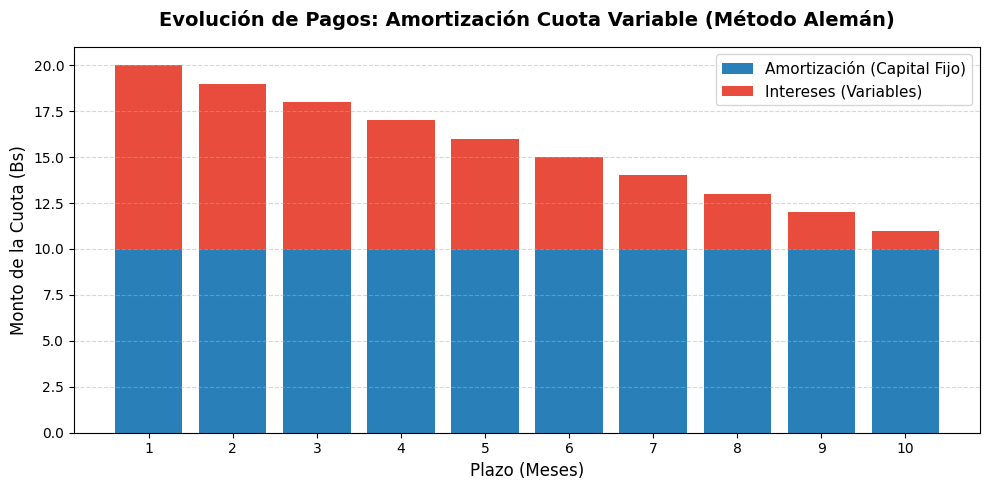

In [245]:
plt.figure(figsize=(10, 5))

plt.bar(df_variable['Mes'], df_variable['Amortización'], 
        label='Amortización (Capital Fijo)', color='#2980b9')

plt.bar(df_variable['Mes'], df_variable['Intereses'], 
        bottom=df_variable['Amortización'], 
        label='Intereses (Variables)', color='#e74c3c')

plt.title('Evolución de Pagos: Amortización Cuota Variable (Método Alemán)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Plazo (Meses)', fontsize=12)
plt.ylabel('Monto de la Cuota (Bs)', fontsize=12)
plt.xticks(df_variable['Mes'])

plt.legend(loc='upper right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Capítulo 3: Evaluación de Proyectos y Bonos

La valoración de instrumentos de renta fija (bonos) requiere traer a Valor Presente todos los flujos de caja futuros que el bono promete pagar. Esto incluye tanto los pagos periódicos (cupones) como la devolución del capital final (valor nominal o de redención).

### Resolución del Problema 4 (JCS S.R.L.)
La compañía JCS S.R.L. emite bonos con valor nominal de **$100 cada uno redimibles a la par** a un plazo de 5 años. La tasa de cupón que ofrece es del **12.8% anual pagadero cada trimestre**. 

¿Qué precio se debe pagar por cada bono si se adquieren un año antes de su vencimiento y se desea un rendimiento del **15.6% capitalizable cada mes**?.

In [246]:
# 1. Variables del Bono JCS S.R.L.
valor_nominal = 100                 # Valor Nominal (redimible a la par)
tasa_cupon_anual = 0.128            # 12.8% anual
frecuencia_cupones = 4              # Pagadero cada trimestre (4 veces al año)
plazo_restante_anios = 1            # Se adquiere 1 año antes del vencimiento

# 2. Variables del Rendimiento Esperado (Inversionista)
j_rendimiento = 0.156               # Tasa nominal deseada: 15.6%
frecuencia_rendimiento = 12         # Capitalizable cada mes

# 3. Sincronización de Tasas al periodo del Cupón (Trimestral)
# Cuánto paga realmente cada cupón:
cupon_trimestral = valor_nominal * (tasa_cupon_anual / frecuencia_cupones)

# Convertimos la tasa de rendimiento esperada a efectiva trimestral
i_mensual = j_rendimiento / frecuencia_rendimiento
i_trimestral_efectiva = (1 + i_mensual)**3 - 1

# 4. Sincronización del tiempo
periodos_restantes = plazo_restante_anios * frecuencia_cupones

# 5. Valoración del Bono (Valor Presente)
# VP_Bonos = Valor Presente de los Cupones (Anualidad) + Valor Presente del Nominal
factor_descuento = (1 + i_trimestral_efectiva)**periodos_restantes

# Anualidad vencida para los cupones
vp_cupones = cupon_trimestral * ((1 - (1 / factor_descuento)) / i_trimestral_efectiva)

# Traer al presente el pago final del bono
vp_nominal = valor_nominal / factor_descuento

precio_justo = vp_cupones + vp_nominal

print("--- VALORACIÓN DE BONO JCS S.R.L. ---")
print(f"Valor del Cupón Trimestral  : ${cupon_trimestral:.2f}")
print(f"Tasa efectiva trimestral exigida : {i_trimestral_efectiva * 100:.4f}%")
print(f"\nPRECIO DE COMPRA RECOMENDADO : ${precio_justo:.2f}")

if precio_justo < valor_nominal:
    print("Conclusión: El bono debe comprarse 'Bajo la par' (con descuento) para alcanzar el rendimiento exigido.")
elif precio_justo > valor_nominal:
    print("Conclusión: El bono se cotiza 'Sobre la par' (con prima).")
else:
    print("Conclusión: El bono se cotiza 'A la par'.")

--- VALORACIÓN DE BONO JCS S.R.L. ---
Valor del Cupón Trimestral  : $3.20
Tasa efectiva trimestral exigida : 3.9509%

PRECIO DE COMPRA RECOMENDADO : $97.27
Conclusión: El bono debe comprarse 'Bajo la par' (con descuento) para alcanzar el rendimiento exigido.


## 2.5 Gradientes Anticipados

Los gradientes son movimientos periódicos que aumentan o disminuyen siguiendo un patrón matemático. Pueden ser **aritméticos** (suman/restan una cantidad fija de dinero) o **geométricos** (crecen/decrecen en un porcentaje).

Resolveremos el Problema 1 de la sección 2.5:
> *Considere una anualidad anticipada con gradiente aritmético cuyo valor inicial es de Bs. 450 y el incremento es de Bs 25 cada mes, además se sabe que la cuenta de ahorro paga un interés del 8% anual capitalizable trimestralmente. ¿Cuánto se habrá ahorrado después de 6.75 años?*

Dado que es un movimiento **anticipado**, cada depósito empieza a generar intereses desde el instante en que entra a la cuenta.

In [247]:
import pandas as pd

# 1. Variables del Problema
cuota_inicial = 450         # Valor inicial en Bs.
incremento = 25             # Gradiente aritmético (Bs. 25 cada mes)
tasa_nominal = 0.08         # 8% anual
plazo_anios = 6.75          # Tiempo en años

# 2. Sincronización de Tiempo y Tasas
meses_totales = int(plazo_anios * 12)  # 6.75 años = 81 meses

# La tasa es 8% anual cap. trimestralmente -> Tasa efectiva trimestral = 0.08 / 4
i_trimestral = tasa_nominal / 4

# Llevamos la tasa trimestral a mensual: (1 + i_trim)^1 = (1 + i_men)^3
i_mensual = (1 + i_trimestral)**(1/3) - 1

# 3. Simulación del Gradiente Anticipado
saldo = 0
cuota_actual = cuota_inicial
historial_ahorro = []

for mes in range(1, meses_totales + 1):
    # Al ser anticipado, el dinero entra al INICIO del mes
    saldo += cuota_actual
    
    # El nuevo saldo genera intereses durante ese mes
    interes_ganado = saldo * i_mensual
    saldo += interes_ganado
    
    # Guardamos el registro
    historial_ahorro.append({
        'Mes': mes,
        'Depósito (Bs)': round(cuota_actual, 2),
        'Interés Ganado (Bs)': round(interes_ganado, 2),
        'Saldo Final (Bs)': round(saldo, 2)
    })
    
    # Preparamos la cuota para el SIGUIENTE mes (sumando el gradiente)
    cuota_actual += incremento

# 4. Resultados
df_gradiente = pd.DataFrame(historial_ahorro)
saldo_final = df_gradiente['Saldo Final (Bs)'].iloc[-1]

print("--- RESULTADO DEL GRADIENTE ANTICIPADO ---")
print(f"Total de meses ahorrando  : {meses_totales}")
print(f"Tasa efectiva mensual     : {i_mensual * 100:.4f}%")
print(f"\nMONTO TOTAL ACUMULADO     : Bs. {saldo_final:,.2f}")

# Mostramos los primeros 5 y los últimos 5 meses para ver la evolución
display(pd.concat([df_gradiente.head(), df_gradiente.tail()]))

--- RESULTADO DEL GRADIENTE ANTICIPADO ---
Total de meses ahorrando  : 81
Tasa efectiva mensual     : 0.6623%

MONTO TOTAL ACUMULADO     : Bs. 146,146.44


,Mes,Depósito (Bs),Interés Ganado (Bs),Saldo Final (Bs)
0,1,450,2.98,452.98
1,2,475,6.15,934.13
2,3,500,9.50,1443.62
3,4,525,13.04,1981.66
4,5,550,16.77,2548.43
76,77,2350,873.60,132783.80
77,78,2375,895.12,136053.91
78,79,2400,916.94,139370.85
79,80,2425,939.07,142734.93
80,81,2450,961.52,146146.44


## 3.0 Evaluación de Proyectos y Bonos (Rendimiento)

Cuando compramos un bono en el mercado secundario, el precio que pagamos ($VP$) suele ser diferente al valor nominal. Para descubrir la rentabilidad real de nuestra inversión, necesitamos hallar la **Tasa Interna de Retorno (TIR)**.

Resolveremos el Problema 1 de la sección 3.0.2:
> *Dolores Daria compra 10 bonos por un valor 500€ cada uno, si todos tienen un valor de redencion de 600€ y una tasa cupon del 2% efectiva anual, si estos bonos se redimen en 12 años, ¿Cual seria su rendimiento de cada bono?*

In [248]:
# Si no tienes instalada la librería, la instalamos directamente desde Jupyter:
# %pip install numpy-financial
import numpy_financial as npf

# 1. Variables del Bono de Dolores Daria (Análisis por 1 bono)
precio_compra = -500     # Flujo de salida (inversión inicial en negativo)
valor_redencion = 600    # Lo que pagan al final del año 12
tasa_cupon = 0.02        # 2% anual sobre el valor nominal de emisión (asumiremos nominal = 500)
anios_redencion = 12     # Plazo

# Calculamos el valor en dinero de cada cupón anual
pago_cupon = 500 * tasa_cupon  # 10 euros anuales

# 2. Construcción del Flujo de Caja (Cash Flow)
# Año 0: Desembolso inicial
flujos_caja = [precio_compra]

# Año 1 al 11: Solo se cobra el cupón
for anio in range(1, anios_redencion):
    flujos_caja.append(pago_cupon)

# Año 12: Se cobra el último cupón + el valor de redención
flujos_caja.append(pago_cupon + valor_redencion)

# 3. Cálculo del Rendimiento (TIR)
rendimiento_bono = npf.irr(flujos_caja)

print("--- ANÁLISIS DE RENDIMIENTO DEL BONO ---")
print(f"Flujos de caja proyectados: {flujos_caja}")
print(f"\nRENDIMIENTO REAL DEL BONO (TIR): {rendimiento_bono * 100:.4f}% anual")

# Análisis de cotización
if abs(precio_compra) < valor_redencion:
    print("Estado: El bono se compró 'Bajo la par' (con descuento).")
elif abs(precio_compra) > valor_redencion:
    print("Estado: El bono se compró 'Sobre la par' (con prima).")
else:
    print("Estado: El bono se compró 'A la par'.")

--- ANÁLISIS DE RENDIMIENTO DEL BONO ---
Flujos de caja proyectados: [-500, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 610.0]

RENDIMIENTO REAL DEL BONO (TIR): 3.3792% anual
Estado: El bono se compró 'Bajo la par' (con descuento).


# Caso Práctico Avanzado: Análisis de Riesgo Crediticio

En el mundo real, los bancos no solo calculan cuotas, sino que evalúan si el cliente tiene la capacidad de pagarlas. 

### Problema Reto: El Crédito de Alejandra
Alejandra está interesada en un crédito hipotecario de **Bs. 1,450,530**. El Banco Chinpilin le ofrece una tasa de interés del **6% anual capitalizable mensualmente**. 

Alejandra tiene un salario mensual de **Bs. 18,850** y el informe de riesgo del banco establece que solo puede usar hasta el **40% de su salario** como capacidad de pago. 

**Objetivo:** Determinar su cuota mensual máxima y calcular matemáticamente cuántos meses tardará en pagar la deuda aplicando a un plan de cuota fija.

In [249]:
import math
import pandas as pd

# 1. Variables del Perfil del Cliente y Préstamo
prestamo_vp = 1450530      # Valor Presente del préstamo (Bs)
salario_mensual = 18850    # Ingreso de Alejandra (Bs)
limite_riesgo = 0.40       # Capacidad máxima de pago (40%)
tasa_nominal = 0.06        # 6% anual

# 2. Análisis de Capacidad de Pago
cuota_maxima = salario_mensual * limite_riesgo
i_mensual = tasa_nominal / 12  # Tasa efectiva mensual (0.5%)

print("--- REPORTE DE RIESGO CREDITICIO ---")
print(f"Salario declarado      : Bs. {salario_mensual:,.2f}")
print(f"Cuota máxima permitida : Bs. {cuota_maxima:,.2f} (Capacidad del {limite_riesgo*100}%)")

# 3. Verificación de Viabilidad del Crédito
# El interés del primer mes no puede ser mayor a la cuota máxima.
interes_mes_1 = prestamo_vp * i_mensual

if interes_mes_1 >= cuota_maxima:
    print(f"\n[ALERTA ROJA] Crédito inviable. Los intereses mensuales (Bs. {interes_mes_1:,.2f}) superan la capacidad de pago.")
else:
    print(f"Viabilidad             : APROBADA (Los intereses iniciales son Bs. {interes_mes_1:,.2f})")
    
    # 4. Despeje del Tiempo (n) usando Logaritmos
    # Partimos de la fórmula de Anualidad Vencida (Valor Presente): 
    # VP = C * [ (1 - (1+i)^-n) / i ]
    # Despejando n: n = - log(1 - (VP * i) / C) / log(1 + i)
    
    numerador = 1 - ((prestamo_vp * i_mensual) / cuota_maxima)
    n_meses = -math.log(numerador) / math.log(1 + i_mensual)
    
    anios_totales = n_meses / 12
    
    print("\n--- PROYECCIÓN DE AMORTIZACIÓN ---")
    print(f"Para saldar el préstamo pagando Bs. {cuota_maxima:,.2f} mensuales:")
    print(f"Tiempo estimado: {math.ceil(n_meses)} meses (aprox. {anios_totales:.2f} años).")
    
    # Exportamos un pequeño resumen a CSV usando la coma como separador de listas 
    # para asegurar la lectura nativa en Excel.
    resumen_credito = pd.DataFrame([{
        'Cliente': 'Alejandra',
        'Prestamo (Bs)': prestamo_vp,
        'Cuota Asignada (Bs)': cuota_maxima,
        'Plazo (Meses)': math.ceil(n_meses)
    }])
    resumen_credito.to_csv('reporte_riesgo_alejandra.csv', sep=',', index=False)

--- REPORTE DE RIESGO CREDITICIO ---
Salario declarado      : Bs. 18,850.00
Cuota máxima permitida : Bs. 7,540.00 (Capacidad del 40.0%)
Viabilidad             : APROBADA (Los intereses iniciales son Bs. 7,252.65)

--- PROYECCIÓN DE AMORTIZACIÓN ---
Para saldar el préstamo pagando Bs. 7,540.00 mensuales:
Tiempo estimado: 656 meses (aprox. 54.59 años).
